# 공공 자전거 장기 연체 예측 (더미 데이터 버전)
- 데이터 : `data/dummy_rentals.csv` (밤 대여, 주말, 신규 이용자 → 연체↑ / 프리미엄 → 연체↓ 패턴을 넣은 데이터)
- 목적 : 원래 데이터(AUC 약 0.49)와 비교해서, 패턴이 있으면 모델이 찾아내는지 확인

## [STEP 1] 파생변수 & 정답지(Target)
- `duration_min` = `return_time - rent_time` (분 단위)
- `is_overdue_100m` = `duration_min > 100` 이면 1 (예측 대상)
- `hour`, `weekday` = `rent_time` 기준 시간대, 요일 → 연체 비율, "전부 정상" 예측 시 정확도 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"    # 윈도우 기본 한글 폰트 (맑은 고딕)
plt.rcParams["axes.unicode_minus"] = False       # 마이너스(-) 기호 깨짐 방지

df = pd.read_csv("data/dummy_rentals.csv", parse_dates=["rent_time", "return_time"])

print(f"전체 행, 열 수 : {df.shape}")
print("[컬럼별 자료형]")
print(df.dtypes)

전체 행, 열 수 : (13501, 16)
[컬럼별 자료형]
rental_id                      str
bike_id                        str
user_id                        str
rent_time           datetime64[us]
return_time         datetime64[us]
distance_km                float64
fee                          int64
payment_method                 str
station_id                     str
bike_type                      str
gear_count                 float64
manufacture_year           float64
daily_fee                  float64
station_name                   str
district                       str
duration_min                 int64
dtype: object


In [2]:
# 1. 대여시간(분)
diff = df["return_time"] - df["rent_time"]
df["duration_min"] = diff.dt.total_seconds() / 60

print("[대여 시간(분) 계산 결과 - 상위 5행]")
display(df[["rent_time", "return_time", "duration_min"]].head())

[대여 시간(분) 계산 결과 - 상위 5행]


,rent_time,return_time,duration_min
0,2022-04-18 20:28:00,2022-04-18 21:34:00,66.0
1,2022-05-19 09:53:00,2022-05-19 10:30:00,37.0
2,2022-09-07 16:20:00,2022-09-07 17:29:00,69.0
3,2022-10-11 06:39:00,2022-10-11 07:40:00,61.0
4,2022-07-11 10:15:00,2022-07-11 12:09:00,114.0


In [3]:
# 2. 정답지 : 100분 초과면 1
df["is_overdue_100m"] = (df["duration_min"] > 100).astype(int)

print("[연체 여부별 건수] 0 = 정상, 1 = 연체")
print(df["is_overdue_100m"].value_counts())

[연체 여부별 건수] 0 = 정상, 1 = 연체
is_overdue_100m
0    11372
1     2129
Name: count, dtype: int64


In [4]:
# 3. 대여 시점 기준 시간대, 요일
df["hour"] = df["rent_time"].dt.hour
df["weekday"] = df["rent_time"].dt.weekday

print("[시간대, 요일 추출 결과 - 상위 5행]")
display(df[["rent_time", "hour", "weekday"]].head())

[시간대, 요일 추출 결과 - 상위 5행]


,rent_time,hour,weekday
0,2022-04-18 20:28:00,20,0
1,2022-05-19 09:53:00,9,3
2,2022-09-07 16:20:00,16,2
3,2022-10-11 06:39:00,6,1
4,2022-07-11 10:15:00,10,0


In [5]:
# 4. 연체 비율, "전부 정상" 예측 시 정확도
overdue_ratio = df["is_overdue_100m"].mean()
all_normal_acc = 1 - overdue_ratio

print(f"전체 행 수 : {len(df):,}")
print(f"연체 비율 : {overdue_ratio:.2%}")
print(f"'전부 정상' 예측 시 정확도 : {all_normal_acc:.2%}")

전체 행 수 : 13,501
연체 비율 : 15.77%
'전부 정상' 예측 시 정확도 : 84.23%


## [STEP 2] users 결합 & 가입 기간(파생변수)
- `users.csv` 를 `user_id` 기준으로 결합 (`how`, `validate` 명시) → 결합 전후 행 수 비교
- 가입 기간(일) = `rent_time - join_date`

In [6]:
# 5. users 불러오기
users = pd.read_csv("data/users.csv", parse_dates=["join_date"])

# 6. 결합
before = len(df)

df = df.merge(
    users,
    on="user_id",
    how="left",
    validate="many_to_one"
)

print(f"결합 전: {before:,}행")
print(f"결합 후: {len(df):,}행")

결합 전: 13,501행
결합 후: 13,501행


In [7]:
# 7. 가입 기간(일) = 대여시점 - 가입일
df["member_days"] = (df["rent_time"] - df["join_date"]).dt.days

print("[가입 기간(일) 요약]")
print(df["member_days"].describe())

[가입 기간(일) 요약]
count    13501.000000
mean        49.932301
std        312.660220
min       -622.000000
25%       -207.000000
50%         42.000000
75%        312.000000
max        720.000000
Name: member_days, dtype: float64


In [8]:
# 확인용 : 가입 기간 음수 원인
neg = df["member_days"] < 0

print(f"가입 기간 음수 : {neg.sum():,}건 ({neg.mean():.2%})")
print(f"대여일 범위 : {df['rent_time'].min()} ~ {df['rent_time'].max()}")
print(f"가입일 범위 : {users['join_date'].min()} ~ {users['join_date'].max()}")

가입 기간 음수 : 6,160건 (45.63%)
대여일 범위 : 2022-01-01 07:26:00 ~ 2022-12-31 22:52:00
가입일 범위 : 2021-01-01 00:00:00 ~ 2023-09-27 00:00:00


In [9]:
# 8. 가입 기간 음수 처리 : 기본은 0으로 대체 (나머지 방법은 마지막에 비교)
df["member_days_raw"] = df["member_days"]                # 원본 보관 (비교 실험용)
df["join_error"] = (df["member_days"] < 0).astype(int)   # 원래 음수였으면 1
df["member_days"] = df["member_days"].clip(lower=0)      # 음수 → 0

print(f"가입 전 대여(음수) : {df['join_error'].sum():,}건 ({df['join_error'].mean():.2%})")
print("[처리 후 가입 기간(일) 요약]")
print(df["member_days"].describe())

가입 전 대여(음수) : 6,160건 (45.63%)
[처리 후 가입 기간(일) 요약]
count    13501.000000
mean       159.521591
std        196.668801
min          0.000000
25%          0.000000
50%         42.000000
75%        312.000000
max        720.000000
Name: member_days, dtype: float64


## [STEP 3] 데이터 누수 탐지
- 기준 : 대여 순간(`rent_time`)에 알 수 있는 값인가? → 반납 후에야 확정되는 값은 제외

In [10]:
print("[현재 컬럼 목록]")
print(df.columns.tolist())

[현재 컬럼 목록]
['rental_id', 'bike_id', 'user_id', 'rent_time', 'return_time', 'distance_km', 'fee', 'payment_method', 'station_id', 'bike_type', 'gear_count', 'manufacture_year', 'daily_fee', 'station_name', 'district', 'duration_min', 'is_overdue_100m', 'hour', 'weekday', 'join_date', 'membership_type', 'member_days', 'member_days_raw', 'join_error']


In [11]:
# 9. 누수 컬럼 (반납 후에야 확정되는 값)
LEAK_COLS = ["return_time", "duration_min", "distance_km", "fee"]

# 누수는 아니지만 학습에 쓰지 않는 컬럼 (ID, 날짜 원본, 비교용)
ID_DATE_COLS = ["rental_id", "bike_id", "user_id", "station_id", "station_name",
                "rent_time", "join_date", "member_days_raw"]

# 정답
TARGET = "is_overdue_100m"

print(f"누수 컬럼 : {LEAK_COLS}")
print(f"제외 컬럼 : {ID_DATE_COLS}")
print(f"정답 : {TARGET}")

# 10. 학습에 쓸 피처 = 전체 - 누수 - 제외 - 정답
DROP_COLS = LEAK_COLS + ID_DATE_COLS + [TARGET]

FEATURES = [c for c in df.columns if c not in DROP_COLS]

print(f"피처 개수 : {len(FEATURES)}")
print(f"피처 목록 : {FEATURES}")

누수 컬럼 : ['return_time', 'duration_min', 'distance_km', 'fee']
제외 컬럼 : ['rental_id', 'bike_id', 'user_id', 'station_id', 'station_name', 'rent_time', 'join_date', 'member_days_raw']
정답 : is_overdue_100m
피처 개수 : 11
피처 목록 : ['payment_method', 'bike_type', 'gear_count', 'manufacture_year', 'daily_fee', 'district', 'hour', 'weekday', 'membership_type', 'member_days', 'join_error']


## [STEP 4] 학습 / 테스트 분할 & 인코딩
- `rent_time` 기준 상위 80% 날짜로 분할 (랜덤 분할 X) → 범주형 인코딩 → 테스트 열을 학습 열에 맞춤

In [12]:
# 11. 시점 기준 분할 (80% : 20%)
cutoff = df["rent_time"].quantile(0.8)

train = df[df["rent_time"] <= cutoff]
test = df[df["rent_time"] > cutoff]

print("=" * 60)

print(f"기준선 : {cutoff}")
print(f"학습 : {len(train):,}행 ({train['rent_time'].min().date()} ~ {train['rent_time'].max().date()})")
print(f"테스트 : {len(test):,}행 ({test['rent_time'].min().date()} ~ {test['rent_time'].max().date()})")
print()
print("=" * 60)

# 12. X, y 분리
X_train = train[FEATURES]
X_test = test[FEATURES]
y_train = train[TARGET]
y_test = test[TARGET]

# 13. 범주형 원핫 인코딩
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

print(f"인코딩 후 학습 열 수 : {X_train.shape[1]}")
print(f"인코딩 후 테스트 열 수 : {X_test.shape[1]}")
print()
print("=" * 60)

# 14. 테스트 열을 학습 열에 맞추기 (없는 열은 0으로 채움)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"학습 열 수 : {X_train.shape[1]}, 테스트 열 수 : {X_test.shape[1]}")
print(f"열 순서까지 같음 : {list(X_train.columns) == list(X_test.columns)}")
print()
print("=" * 60)

# 15. 결측값 확인
na = X_train.isna().sum()

print("[학습 데이터 결측 값 - 1개 이상인 열만]")
print(na[na > 0])
print()
print("=" * 60)

# 16. 결측 채우기 : 학습 데이터의 중앙값으로 (테스트도 같은 값)
med_year = X_train["manufacture_year"].median()

X_train["manufacture_year"] = X_train["manufacture_year"].fillna(med_year)
X_test["manufacture_year"] = X_test["manufacture_year"].fillna(med_year)

print(f"채운 값(학습 중앙값) : {med_year}")
print(f"남은 결측 - 학습 : {X_train.isna().sum().sum()}, 테스트 : {X_test.isna().sum().sum()}")

기준선 : 2022-10-20 16:21:00
학습 : 10,801행 (2022-01-01 ~ 2022-10-20)
테스트 : 2,700행 (2022-10-20 ~ 2022-12-31)

인코딩 후 학습 열 수 : 24
인코딩 후 테스트 열 수 : 24

학습 열 수 : 24, 테스트 열 수 : 24
열 순서까지 같음 : True

[학습 데이터 결측 값 - 1개 이상인 열만]
manufacture_year    1326
dtype: int64

채운 값(학습 중앙값) : 2018.0
남은 결측 - 학습 : 0, 테스트 : 0


## [STEP 5] 누수의 위력 확인
- 누수 컬럼(`duration_min`)을 일부러 넣은 피처 vs 뺀 피처 → RandomForest로 성능 비교

In [13]:
# 17. 누수 포함 피처 만들기 (비교용)
X_train_leak = X_train.copy()
X_test_leak = X_test.copy()

X_train_leak["duration_min"] = train["duration_min"]
X_test_leak["duration_min"] = test["duration_min"]

print("="*60)
print(f"누수 제외 : {X_train.shape[1]}열")
print(f"누수 포함 : {X_train_leak.shape[1]}열")
print()
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42

# 18. 누수 제외 vs 포함 비교
data_sets = {
    "누수 제외": (X_train, X_test),
    "누수 포함": (X_train_leak, X_test_leak)
}

rows = []

for name, (Xtr, Xte) in data_sets.items():
    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)
    model.fit(Xtr, y_train)

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    
    rows.append({
        "피처": name,
        "정확도": accuracy_score(y_test, pred),
        "재현율": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
    })

display(pd.DataFrame(rows).round(4))

누수 제외 : 24열
누수 포함 : 25열



,피처,정확도,재현율,F1,AUC
0,누수 제외,0.8389,0.0,0.0,0.7122
1,누수 포함,1.0000,1.0,1.0,1.0000


## [STEP 6] 모델 비교
- Dummy / LR / LR(balanced) / RF / RF(balanced) → 정확도, 정밀도, 재현율, F1, AUC 비교

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def with_scaler(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])

# 19. 비교할 모델 5개
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LR": with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)),
    "LR(balanced)": with_scaler(LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")),
    "RF": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    "RF(balanced)": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1, class_weight="balanced"),
}

print(list(models.keys()))

['Dummy', 'LR', 'LR(balanced)', 'RF', 'RF(balanced)']


In [15]:
from sklearn.metrics import precision_score

# 20. 모델 5개 학습 & 평가
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_test, pred),
        "정밀도": precision_score(y_test, pred, zero_division=0),
        "재현율": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
    })

result = pd.DataFrame(rows)
display(result.round(4))

,모델,정확도,정밀도,재현율,F1,AUC
0,Dummy,0.8389,0.0000,0.0000,0.0000,0.5000
1,LR,0.8385,0.0000,0.0000,0.0000,0.6520
2,LR(balanced),0.6115,0.2363,0.6322,0.3440,0.6506
3,RF,0.8389,0.0000,0.0000,0.0000,0.7122
4,RF(balanced),0.6974,0.2937,0.6253,0.3997,0.7217


## [STEP 7] 혼동행렬과 지표
- `RF(balanced)` 의 TP, FN, FP, TN → 자전거 관점에서 해석, FN vs FP 중 치명적인 쪽 판단

In [16]:
from sklearn.metrics import confusion_matrix

# 21. RF(balanced) 혼동행렬
rf_bal = models["RF(balanced)"]
pred = rf_bal.predict(X_test)

cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()

print("[혼동행렬]")
print(cm)
print(f"TP : {tp}, FN : {fn}, FP : {fp}, TN : {tn}")

[혼동행렬]
[[1611  654]
 [ 163  272]]
TP : 272, FN : 163, FP : 654, TN : 1611


## [STEP 8] 비용 기반 임계값 선택
- 임계값 0.05 ~ 0.95 → TP, FN, FP, 재현율, 정밀도, 총비용(FN × 15,000 + FP × 2,000) → 총비용 최소 임계값 찾기

In [17]:
COST_FN = 15000   # 연체를 놓침
COST_FP = 2000    # 정상을 의심

# 22. 임계값별 비용 계산
proba = rf_bal.predict_proba(X_test)[:, 1]   # 연체일 확률

rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred_t = (proba >= t).astype(int)        # 확률이 t 이상이면 연체로 예측
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    rows.append({
        "임계값": round(t, 2),
        "TP": tp, "FN": fn, "FP": fp,
        "재현율": recall_score(y_test, pred_t, zero_division=0),
        "정밀도": precision_score(y_test, pred_t, zero_division=0),
        "총비용": fn * COST_FN + fp * COST_FP,
    })

cost_df = pd.DataFrame(rows)
display(cost_df.round(3))
print()
print("="*60)

# 23. 총비용 최소 임계값
best_idx = cost_df["총비용"].idxmin()
best = cost_df.loc[best_idx]

print("[총비용 최소 지점]")
print(f"임계값 : {best['임계값']:.2f}")
print(f"TP : {best['TP']:.0f}, FN : {best['FN']:.0f}, FP : {best['FP']:.0f}")
print(f"재현율 : {best['재현율']:.3f}, 정밀도 : {best['정밀도']:.3f}")
print(f"총비용 : {best['총비용']:,.0f}원")
print()
print("="*60)

# 24. "아무 예측 안 함" 비용과 비교
base_fn = y_test.sum()                 # 전부 정상 예측 → 실제 연체 전부가 FN
base_cost = base_fn * COST_FN          # FP는 0건

saving = base_cost - best["총비용"]

print(f"아무 예측 안 함 : FN {base_fn}건 → {base_cost:,.0f}원")
print(f"최적 임계값({best['임계값']:.2f}) : {best['총비용']:,.0f}원")
print(f"절감액 : {saving:,.0f}원 ({saving / base_cost:.1%} 절감)")

,임계값,TP,FN,FP,재현율,정밀도,총비용
0,0.05,435,0,2265,1.000,0.161,4530000
1,0.10,435,0,2265,1.000,0.161,4530000
2,0.15,435,0,2265,1.000,0.161,4530000
3,0.20,435,0,2233,1.000,0.163,4466000
4,0.25,430,5,2132,0.989,0.168,4339000
5,0.30,425,10,1923,0.977,0.181,3996000
6,0.35,419,16,1844,0.963,0.185,3928000
7,0.40,408,27,1779,0.938,0.187,3963000
8,0.45,318,117,912,0.731,0.259,3579000
9,0.50,272,163,654,0.625,0.294,3753000



[총비용 최소 지점]
임계값 : 0.45
TP : 318, FN : 117, FP : 912
재현율 : 0.731, 정밀도 : 0.259
총비용 : 3,579,000원

아무 예측 안 함 : FN 435건 → 6,525,000원
최적 임계값(0.45) : 3,579,000원
절감액 : 2,946,000원 (45.1% 절감)


## [STEP 9] 피처 중요도와 해석
- 최종 모델(`RF(balanced)`) 피처 중요도 상위 5개 막대그래프 → 운영팀 모니터링 포인트 3줄 정리

[피처 중요도 상위 5개]
hour                       0.4817
weekday                    0.1853
membership_type_BASIC      0.0759
membership_type_PREMIUM    0.0727
member_days                0.0668
dtype: float64


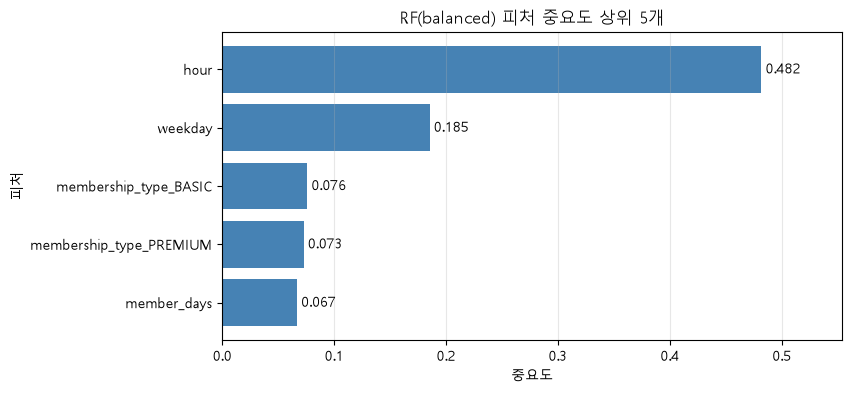

In [18]:
# 25. 피처 중요도 상위 5개
imp = pd.Series(rf_bal.feature_importances_, index=X_train.columns)
top5 = imp.sort_values(ascending=False).head(5)

print("[피처 중요도 상위 5개]")
print(top5.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5.index[::-1], top5.values[::-1], color="steelblue")

ax.bar_label(bars, fmt="%.3f", padding=3)   # 막대 끝에 값 표시
ax.set_xlabel("중요도")
ax.set_ylabel("피처")                        # y축 이름 추가
ax.set_title("RF(balanced) 피처 중요도 상위 5개")
ax.set_xlim(0, top5.max() * 1.15)           # 숫자가 잘리지 않게 오른쪽 여유
ax.grid(alpha=0.3, axis="x")
plt.show()

#### 운영팀 보고
1. 연체 예측에 가장 중요한 정보는 **대여 시간대(0.48) > 요일(0.19) > 멤버십 등급** 순이며, 특히 **20시 이후·주말 대여**를 우선 모니터링해야 한다.
2. 모델 AUC 약 0.72 로 연체를 어느 정도 구분하며, 임계값 0.45 에서 총비용 3,579,000원으로 **전원 독촉(4,530,000원)보다 약 95만 원 절감**된다.
3. 프리미엄 회원은 연체율이 낮으므로(10.5% vs 17.9%) 독촉 대상에서 우선순위를 낮출 수 있다.

## [추가 실험 1] 가입 기간 음수 처리 4가지 비교
- ① 삭제 / ② 0으로 대체 / ③ -1로 표시 / ④ 중앙값 대체 → 같은 모델(RF balanced), 같은 지표로 비교

In [19]:
# 26. 처리 방법별로 데이터를 만들고 RF(balanced) 학습 → 지표 반환
def run(method):
    d = df.copy()
    raw = d["member_days_raw"]

    if method == "① 삭제":
        d = d[raw >= 0].copy()                    # 음수가 아닌 행만 남김
        d["member_days"] = d["member_days_raw"]
    elif method == "② 0으로 대체":
        d["member_days"] = raw.clip(lower=0)
    elif method == "③ -1로 표시":
        d["member_days"] = raw.where(raw >= 0, -1)   # 음수 → -1
    elif method == "④ 중앙값 대체":
        d["member_days"] = raw.where(raw >= 0)       # 음수 → NaN (분할 후 채움)

    # 분할 (STEP 4와 같은 기준선)
    tr = d[d["rent_time"] <= cutoff]
    te = d[d["rent_time"] > cutoff]

    # 인코딩 + 열 맞추기
    Xtr = pd.get_dummies(tr[FEATURES])
    Xte = pd.get_dummies(te[FEATURES]).reindex(columns=Xtr.columns, fill_value=0)

    # 결측 채우기 : 학습 데이터 중앙값으로 (④의 member_days 포함)
    for col in ["manufacture_year", "member_days"]:
        med = Xtr[col].median()
        Xtr[col] = Xtr[col].fillna(med)
        Xte[col] = Xte[col].fillna(med)

    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED,
                                   n_jobs=-1, class_weight="balanced")
    model.fit(Xtr, tr[TARGET])

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    y = te[TARGET]

    return {
        "방법": method,
        "학습 행": len(Xtr),
        "테스트 행": len(Xte),
        "정확도": accuracy_score(y, pred),
        "재현율": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "AUC": roc_auc_score(y, proba),
    }

methods = ["① 삭제", "② 0으로 대체", "③ -1로 표시", "④ 중앙값 대체"]
compare = pd.DataFrame([run(m) for m in methods])

print("[가입 기간 음수 처리 방법별 비교 - RF(balanced)]")
display(compare.round(4))

[가입 기간 음수 처리 방법별 비교 - RF(balanced)]


,방법,학습 행,테스트 행,정확도,재현율,F1,AUC
0,① 삭제,5468,1873,0.7069,0.6022,0.3754,0.7177
1,② 0으로 대체,10801,2700,0.6974,0.6253,0.3997,0.7217
2,③ -1로 표시,10801,2700,0.6963,0.6207,0.3971,0.7223
3,④ 중앙값 대체,10801,2700,0.6948,0.6437,0.4046,0.7203


#### 결과
- 네 방법 모두 AUC 0.72 근처(0.7177 ~ 0.7223)로 차이가 거의 없음 → 가입 기간 음수 처리 방법은 성능에 큰 영향 없음
- 원래 데이터(AUC 약 0.49)와 달리, 처리 방법과 관계없이 모델이 패턴을 찾아냄

## [추가 실험 2] 피처별 단독 예측력 확인
- 피처 하나씩 AUC 계산 (0.5 = 구분 못 함) → 데이터 자체에 연체를 예측할 정보가 있는지 확인

In [20]:
# 27. 숫자형 피처별 단독 AUC
num_cols = ["member_days", "hour", "weekday", "manufacture_year", "daily_fee", "gear_count"]

auc_rows = []
for col in num_cols:
    x = df[col].fillna(df[col].median())        # 결측은 중앙값으로
    auc = roc_auc_score(df["is_overdue_100m"], x)      # 정답, 피처값
    auc_rows.append({"피처": col, "단독 AUC": auc})

print("[피처별 단독 AUC - 0.5에 가까울수록 예측력 없음]")
display(pd.DataFrame(auc_rows).round(3))

[피처별 단독 AUC - 0.5에 가까울수록 예측력 없음]


,피처,단독 AUC
0,member_days,0.493
1,hour,0.635
2,weekday,0.588
3,manufacture_year,0.505
4,daily_fee,0.493
5,gear_count,0.493


In [21]:
# 28. 범주형 피처별 그룹 연체 비율
cat_cols = ["bike_type", "payment_method", "membership_type", "district"]

for col in cat_cols:
    rate = df.groupby(col)["is_overdue_100m"].mean()
    print(f"[{col}] 그룹별 연체 비율 (차이 : {rate.max() - rate.min():.1%}p)")
    print(rate.map("{:.1%}".format))
    print()

[bike_type] 그룹별 연체 비율 (차이 : 1.2%p)
bike_type
일반    16.0%
전동    14.8%
Name: is_overdue_100m, dtype: str

[payment_method] 그룹별 연체 비율 (차이 : 0.4%p)
payment_method
APP           15.9%
CARD          15.6%
MEMBERSHIP    15.8%
Name: is_overdue_100m, dtype: str

[membership_type] 그룹별 연체 비율 (차이 : 7.4%p)
membership_type
BASIC      17.9%
PREMIUM    10.5%
Name: is_overdue_100m, dtype: str

[district] 그룹별 연체 비율 (차이 : 6.8%p)
district
강남구    18.7%
강동구    15.3%
강북구    15.6%
강서구    14.4%
관악구    15.3%
광진구    15.3%
구로구    11.9%
금천구    17.1%
노원구    15.9%
도봉구    15.6%
Name: is_overdue_100m, dtype: str



#### 결과
- 단독 AUC : `hour` 0.635, `weekday` 0.588 → 넣은 규칙(밤 대여 +25%, 주말 +10%)이 그대로 드러남
- `membership_type` : BASIC 17.9% vs PREMIUM 10.5% (7.4%p 차이) → 프리미엄 -7% 규칙과 일치
- `member_days` 0.493 : 신규 이용자 규칙(+20%)은 해당 행이 약 3%뿐이라 전체 예측력은 작음
- 나머지 피처(`daily_fee`, `gear_count` 등)는 0.5 근처 → 규칙을 넣지 않은 피처는 예측력 없음